# ÉquiAlgo : modèle corrigé

Objectif : attribuer les bourses aux candidat·es d'évaluation avec la règle du comité historique, sans la pénalité qu'il applique aux régions éloignées. Le taux d'octroi doit rester dans l'enveloppe fixée par le brief ; hors de cette enveloppe, la section technique vaut zéro.

Le carnet écrit `predictions.csv` à la racine du projet et `output/modele.json`.

## Paramètres

Chemins, graine, taux cible, enveloppe, réglages des modèles, régions, groupes et grille du front de Pareto. Les réglages de la figure (section 5) et les seuils du plan de surveillance (section 7) sont fixés dans leur section. Tous les résultats sont calculés à partir de ces valeurs et des données.

In [1]:
import codecs
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity
from IPython.display import Markdown, display
from matplotlib.colors import to_rgba
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RACINE = Path.cwd()
CHEMIN_HISTORIQUE = RACINE / "data" / "donnees_demandes.csv"
CHEMIN_EVALUATION = RACINE / "data" / "candidats_evaluation.csv"
CHEMIN_PREDICTIONS = RACINE / "predictions.csv"
CHEMIN_MODELE_JSON = RACINE / "output" / "modele.json"
CHEMIN_FIGURE = RACINE / "figures" / "front_pareto.png"

GRAINE = 42
TAUX_CIBLE = 0.40
ENVELOPPE = (0.36, 0.44)
PART_TEST = 0.3
N_BOOTSTRAP = 200
N_ARBRES = 300
MIN_FEUILLE = 20
MAX_ITERATIONS = 5000
ECART_EO_BRIEF = 0.270
DECIMALES_JSON = 6

REGIONS_CENTRE = ("Montreal", "Capitale-Nationale")
REGIONS_ELOIGNEES = ("Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine")
REGIONS = (*REGIONS_CENTRE, *REGIONS_ELOIGNEES)
REGION_REFERENCE = "Montreal"
REGIONS_HORS_REFERENCE = tuple(region for region in REGIONS if region != REGION_REFERENCE)
CENTRE = "Centre"
ELOIGNEE = "Eloignee"
LIBELLES_GROUPES = {CENTRE: "grands centres", ELOIGNEE: "régions éloignées"}

IDENTIFIANT = "id_candidat"
CIBLE = "decision_octroi"
COTE_R = "cote_r_equivalent"
REVENU = "revenu_familial_estime"
HEURES = "heures_travail_semaine"
DISTANCE = "distance_domicile_campus_km"
PROGRAMME = "programme_etudes"
REGION = "region_administrative"
CODE_POSTAL = "code_postal_3"
PREMIERE_GENERATION = "premiere_generation_universitaire"
COLONNES_EVALUATION = (
    IDENTIFIANT,
    COTE_R,
    PROGRAMME,
    REGION,
    CODE_POSTAL,
    REVENU,
    HEURES,
    DISTANCE,
    PREMIERE_GENERATION,
)
COLONNES_HISTORIQUE = (*COLONNES_EVALUATION, CIBLE)
COLONNES_PRODUCTION = COLONNES_EVALUATION[1:]
CATEGORIELLES = (PROGRAMME, REGION, CODE_POSTAL)
VARIABLES_SANS_REGION = (COTE_R, PROGRAMME, REVENU, HEURES, DISTANCE, PREMIERE_GENERATION)
CRITERES_CONTINUS = (COTE_R, REVENU, HEURES)
VARIABLE_ELOIGNEE = "region_eloignee"
VARIABLES_REGIONALES = (VARIABLE_ELOIGNEE, *REGIONS_HORS_REFERENCE)
MOTIF_IDENTIFIANT = r"C\d{6}"
BORNES_COTE_R = (15, 40)
VALEURS_BINAIRES = (0, 1)

GRILLE_LAMBDA = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2)
LAMBDA_RETENU = 1.0
N_POINTS_QUOTAS = 6
BORNES_GRADIENT = (0.01, 0.05, 0.10)

ESPACE_INSECABLE = " "
SIGNE_MOINS = "−"


def texte_nombre(valeur, decimales=0):
    texte = f"{valeur:,.{decimales}f}".replace(",", ESPACE_INSECABLE).replace(".", ",")
    return texte.replace("-", SIGNE_MOINS)


def texte_pourcent(valeur, decimales=1):
    return f"{texte_nombre(100 * valeur, decimales)}{ESPACE_INSECABLE}%"


def texte_signe(valeur, decimales=3):
    prefixe = "+" if round(valeur, decimales) > 0 else ""
    return prefixe + texte_nombre(valeur, decimales)


def afficher(texte):
    display(Markdown(texte))


taux_minimal, taux_maximal = ENVELOPPE
afficher(
    f"Enveloppe : taux d'octroi entre {texte_pourcent(taux_minimal, 0)} et "
    f"{texte_pourcent(taux_maximal, 0)}. "
    f"Taux cible : {texte_pourcent(TAUX_CIBLE, 0)}. Graine : {GRAINE}."
)

Enveloppe : taux d'octroi entre 36 % et 44 %. Taux cible : 40 %. Graine : 42.

## 1. Chargement et validation des données

Les deux fichiers sont vérifiés avant tout calcul : colonnes attendues, aucune valeur manquante, identifiants uniques, bien formés et disjoints entre les deux fichiers, cinq régions, cote R dans sa plage, variables binaires. Une anomalie arrête le carnet.

In [2]:
def exiger(condition, message):
    if not condition:
        raise ValueError(message)


def valider(donnees, nom):
    exiger(donnees.notna().all().all(), f"{nom} : valeurs manquantes")
    exiger(donnees[IDENTIFIANT].is_unique, f"{nom} : identifiants en double")
    exiger(donnees[IDENTIFIANT].str.fullmatch(MOTIF_IDENTIFIANT).all(), f"{nom} : identifiant mal formé")
    exiger(set(donnees[REGION]) == set(REGIONS), f"{nom} : régions inattendues")
    exiger(donnees[COTE_R].between(*BORNES_COTE_R).all(), f"{nom} : cote R hors plage")
    exiger(
        donnees[PREMIERE_GENERATION].isin(VALEURS_BINAIRES).all(), f"{nom} : première génération non binaire"
    )


def charger(chemin, colonnes):
    donnees = pd.read_csv(chemin)
    exiger(tuple(donnees.columns) == colonnes, f"{chemin.name} : colonnes inattendues")
    valider(donnees, chemin.name)
    return donnees


def groupe(regions):
    return np.where(pd.Series(regions).isin(REGIONS_ELOIGNEES), ELOIGNEE, CENTRE)


demandes = charger(CHEMIN_HISTORIQUE, COLONNES_HISTORIQUE)
candidats = charger(CHEMIN_EVALUATION, COLONNES_EVALUATION)
exiger(demandes[CIBLE].isin(VALEURS_BINAIRES).all(), "décisions historiques non binaires")
exiger(
    set(demandes[IDENTIFIANT]).isdisjoint(candidats[IDENTIFIANT]), "identifiants communs aux deux fichiers"
)
exiger(set(candidats[PROGRAMME]) <= set(demandes[PROGRAMME]), "programme d'études inconnu")

groupe_demandes = groupe(demandes[REGION])
groupe_candidats = groupe(candidats[REGION])
centre = groupe_candidats == CENTRE
taux_comite = demandes[CIBLE].mean()
nombre_octrois = round(TAUX_CIBLE * len(candidats))
marge = min(TAUX_CIBLE - taux_minimal, taux_maximal - TAUX_CIBLE)
afficher(
    f"{texte_nombre(len(demandes))} décisions historiques du comité et {texte_nombre(len(candidats))} "
    f"candidat·es à évaluer, sans identifiant commun. Part des régions éloignées : "
    f"{texte_pourcent((groupe_demandes == ELOIGNEE).mean())} dans l'historique, "
    f"{texte_pourcent((~centre).mean())} à l'évaluation. Cote R moyenne : "
    f"{texte_nombre(demandes[COTE_R].mean(), 2)} et {texte_nombre(candidats[COTE_R].mean(), 2)}.\n\n"
    f"Le comité a octroyé une bourse à {texte_pourcent(taux_comite)} des demandes. Le taux cible de "
    f"{texte_pourcent(TAUX_CIBLE, 0)} en est la valeur arrondie ; il laisse {texte_nombre(100 * marge)} "
    f"points "
    f"de marge de chaque côté de l'enveloppe et donne {texte_nombre(nombre_octrois)} octrois."
)

10 000 décisions historiques du comité et 4 000 candidat·es à évaluer, sans identifiant commun. Part des régions éloignées : 40,0 % dans l'historique, 40,7 % à l'évaluation. Cote R moyenne : 27,72 et 27,80.

Le comité a octroyé une bourse à 39,9 % des demandes. Le taux cible de 40 % en est la valeur arrondie ; il laisse 4 points de marge de chaque côté de l'enveloppe et donne 1 600 octrois.

## 2. Règle du comité

La règle du comité est estimée par une régression logistique sans pénalisation sur les décisions historiques : cote R, revenu familial et heures travaillées standardisés, programme d'études, première génération, et un effet fixe binaire pour les régions éloignées. Le code postal et la distance sont exclus : le code postal est une étiquette de région, et l'effet de la distance à région égale est faible et incohérent (voir `audit_rapport.ipynb`).

In [3]:
moyennes = demandes[list(CRITERES_CONTINUS)].mean()
ecarts_types = demandes[list(CRITERES_CONTINUS)].std()
type_programme = pd.CategoricalDtype(sorted(demandes[PROGRAMME].unique()))
type_region = pd.CategoricalDtype(REGIONS)


def criteres_standardises(donnees):
    return (donnees[list(CRITERES_CONTINUS)] - moyennes) / ecarts_types


def matrice_criteres(donnees):
    programmes = pd.get_dummies(
        donnees[PROGRAMME].astype(type_programme), prefix="programme", drop_first=True, dtype=float
    )
    generation = donnees[[PREMIERE_GENERATION]].astype(float)
    return pd.concat([criteres_standardises(donnees), programmes, generation], axis=1)


def matrice_comite(donnees):
    eloignee = donnees[REGION].isin(REGIONS_ELOIGNEES).astype(float)
    return matrice_criteres(donnees).assign(**{VARIABLE_ELOIGNEE: eloignee})


def matrice_regions(donnees):
    regions = pd.get_dummies(donnees[REGION].astype(type_region), dtype=float)
    return pd.concat([matrice_criteres(donnees), regions[list(REGIONS_HORS_REFERENCE)]], axis=1)


def ajuster_logit(x, y):
    return LogisticRegression(C=np.inf, max_iter=MAX_ITERATIONS).fit(x, y)


def coefficients(modele, x):
    return pd.Series(modele.coef_[0], index=x.columns)


x_demandes = matrice_comite(demandes)
x_candidats = matrice_comite(candidats)
comite = ajuster_logit(x_demandes, demandes[CIBLE])
coefficients_comite = coefficients(comite, x_demandes)
penalite = coefficients_comite[VARIABLE_ELOIGNEE]
points_cote_r = abs(penalite) / coefficients_comite[COTE_R] * ecarts_types[COTE_R]

tableau_coefficients = pd.concat([pd.Series({"constante": comite.intercept_[0]}), coefficients_comite])
display(tableau_coefficients.rename("coefficient (logit)").round(3).to_frame())
afficher(
    f"La cote R domine. Pénalité des régions éloignées : {texte_signe(penalite, 2)} en logit, "
    f"l'équivalent de {texte_nombre(points_cote_r, 2)} point de cote R à critères égaux."
)

,coefficient (logit)
constante,-0.391
cote_r_equivalent,4.132
revenu_familial_estime,0.755
heures_travail_semaine,0.758
programme_Genie,0.044
programme_Sante,0.055
programme_Sciences,0.018
programme_Sciences sociales,-0.010
premiere_generation_universitaire,-0.049
region_eloignee,-1.995


La cote R domine. Pénalité des régions éloignées : −2,00 en logit, l'équivalent de 1,45 point de cote R à critères égaux.

L'effet fixe binaire est comparé à cinq effets fixes de région (référence Montréal) : si les trois régions éloignées reçoivent la même pénalité et la Capitale-Nationale aucune, l'effet binaire suffit.

In [4]:
def ordre_merite(score, identifiants):
    departage = pd.util.hash_pandas_object(identifiants, index=False).to_numpy()
    return np.lexsort((departage, -np.asarray(score, dtype=float)))


def selectionner(score, identifiants, taux=TAUX_CIBLE):
    effectif = round(taux * len(identifiants))
    decisions = np.zeros(len(identifiants), dtype=int)
    decisions[ordre_merite(score, identifiants)[:effectif]] = 1
    return decisions


def score_comite(modele, x, part_retiree=1.0):
    poids = coefficients(modele, x)
    regionales = poids.index.intersection(VARIABLES_REGIONALES)
    poids[regionales] = poids[regionales] * (1 - part_retiree)
    return x.to_numpy() @ poids.to_numpy() + modele.intercept_[0]


x_regions = matrice_regions(demandes)
comite_regions = ajuster_logit(x_regions, demandes[CIBLE])
effets_regions = coefficients(comite_regions, x_regions)[list(REGIONS_HORS_REFERENCE)]
display(
    pd.DataFrame(
        {
            "groupe": groupe(effets_regions.index),
            "effet fixe (logit, réf. Montreal)": effets_regions.round(3).to_numpy(),
        },
        index=effets_regions.index,
    )
)
decisions_binaire = selectionner(score_comite(comite, x_candidats), candidats[IDENTIFIANT])
decisions_regions = selectionner(
    score_comite(comite_regions, matrice_regions(candidats)), candidats[IDENTIFIANT]
)
effets_eloignes = effets_regions[list(REGIONS_ELOIGNEES)]
effet_capitale = effets_regions["Capitale-Nationale"]
afficher(
    f"Pénalités des trois régions éloignées entre {texte_signe(effets_eloignes.min(), 2)} et "
    f"{texte_signe(effets_eloignes.max(), 2)} ; Capitale-Nationale "
    f"{texte_signe(effet_capitale, 2)}. Une fois la région retirée, les deux "
    f"spécifications donnent la même décision pour "
    f"{texte_pourcent((decisions_binaire == decisions_regions).mean(), 2)} "
    "des candidat·es d'évaluation."
)

,groupe,"effet fixe (logit, réf. Montreal)"
Capitale-Nationale,Centre,-0.054
Bas-Saint-Laurent,Eloignee,-2.045
Cote-Nord,Eloignee,-2.054
Gaspesie-Iles-de-la-Madeleine,Eloignee,-1.938


Pénalités des trois régions éloignées entre −2,05 et −1,94 ; Capitale-Nationale −0,05. Une fois la région retirée, les deux spécifications donnent la même décision pour 100,00 % des candidat·es d'évaluation.

Si le comité applique la même règle partout, des régressions ajustées séparément dans chaque groupe donnent les mêmes pentes ; seule la constante change.

In [5]:
def coefficients_avec_constante(modele, x):
    return pd.concat([pd.Series({"constante": modele.intercept_[0]}), coefficients(modele, x)])


x_criteres_demandes = matrice_criteres(demandes)
colonnes_pentes = {"règle commune": coefficients_avec_constante(comite, x_demandes).drop(VARIABLE_ELOIGNEE)}
for nom, libelle in LIBELLES_GROUPES.items():
    masque = groupe_demandes == nom
    modele_groupe = ajuster_logit(x_criteres_demandes[masque], demandes.loc[masque, CIBLE])
    colonnes_pentes[libelle] = coefficients_avec_constante(modele_groupe, x_criteres_demandes)
pentes = pd.DataFrame(colonnes_pentes)
display(pentes.round(3))
libelle_centre, libelle_eloignee = LIBELLES_GROUPES.values()
ecart_pentes = (pentes[libelle_centre] - pentes[libelle_eloignee])[list(CRITERES_CONTINUS)].abs().max()
ecart_constantes = pentes.loc["constante", libelle_eloignee] - pentes.loc["constante", libelle_centre]
afficher(
    f"Écart maximal entre les deux groupes sur les pentes de la cote R, du revenu et des heures : "
    f"{texte_nombre(ecart_pentes, 3)}. Écart des constantes : {texte_signe(ecart_constantes, 2)}, "
    f"pour une pénalité commune estimée à {texte_signe(penalite, 2)}. L'audit (`audit_rapport.ipynb`) "
    "teste cette égalité des pentes et ne la rejette pas."
)

,règle commune,grands centres,régions éloignées
constante,-0.391,-0.420,-2.261
cote_r_equivalent,4.132,4.113,4.189
revenu_familial_estime,0.755,0.688,0.946
heures_travail_semaine,0.758,0.807,0.713
programme_Genie,0.044,0.064,0.124
programme_Sante,0.055,0.152,-0.028
programme_Sciences,0.018,0.073,-0.007
programme_Sciences sociales,-0.010,0.083,-0.081
premiere_generation_universitaire,-0.049,0.006,-0.122


Écart maximal entre les deux groupes sur les pentes de la cote R, du revenu et des heures : 0,258. Écart des constantes : −1,84, pour une pénalité commune estimée à −2,00. L'audit (`audit_rapport.ipynb`) teste cette égalité des pentes et ne la rejette pas.

Contrôle de fidélité sur le même découpage entraînement / test que le carnet de départ (stratifié, même graine) : la règle du comité, ajustée sur l'entraînement, est comparée au modèle en production (forêt aléatoire du carnet de départ) sur le jeu de test.

In [6]:
def encoder(table_entrainement, table_cible):
    x = pd.get_dummies(table_entrainement[list(COLONNES_PRODUCTION)], columns=list(CATEGORIELLES))
    x_cible = pd.get_dummies(table_cible[list(COLONNES_PRODUCTION)], columns=list(CATEGORIELLES))
    return x, x_cible.reindex(columns=x.columns, fill_value=0)


def foret():
    return RandomForestClassifier(n_estimators=N_ARBRES, min_samples_leaf=MIN_FEUILLE, random_state=GRAINE)


entrainement, test = train_test_split(
    demandes, test_size=PART_TEST, random_state=GRAINE, stratify=demandes[CIBLE]
)
x_entrainement, x_test = encoder(entrainement, test)
production = foret().fit(x_entrainement, entrainement[CIBLE])
exactitude_production = accuracy_score(test[CIBLE], production.predict(x_test))
comite_entrainement = ajuster_logit(matrice_comite(entrainement), entrainement[CIBLE])
x_test_comite = matrice_comite(test)
exactitude_comite = accuracy_score(test[CIBLE], comite_entrainement.predict(x_test_comite))
afficher(
    f"Exactitude sur le jeu de test ({texte_pourcent(PART_TEST, 0)} des décisions, soit "
    f"{texte_nombre(len(test))}) : "
    f"règle du comité "
    f"{texte_pourcent(exactitude_comite)}, modèle en production {texte_pourcent(exactitude_production)}."
)

Exactitude sur le jeu de test (30 % des décisions, soit 3 000) : règle du comité 88,5 %, modèle en production 88,1 %.

Incertitude de la pénalité : la règle est réestimée sur des rééchantillonnages bootstrap des décisions historiques.

In [7]:
def bootstrap_comite(nombre, graine):
    generateur = np.random.default_rng(graine)
    modeles = []
    for _ in range(nombre):
        indices = generateur.integers(len(demandes), size=len(demandes))
        modeles.append(ajuster_logit(x_demandes.iloc[indices], demandes[CIBLE].iloc[indices]))
    return modeles


modeles_bootstrap = bootstrap_comite(N_BOOTSTRAP, GRAINE)
penalites_bootstrap = np.array(
    [coefficients(modele, x_demandes)[VARIABLE_ELOIGNEE] for modele in modeles_bootstrap]
)
penalite_moyenne = penalites_bootstrap.mean()
penalite_ecart_type = penalites_bootstrap.std(ddof=1)
afficher(
    f"Sur {N_BOOTSTRAP} rééchantillonnages : pénalité {texte_signe(penalite_moyenne, 2)} "
    f"± {texte_nombre(penalite_ecart_type, 2)} (moyenne ± écart-type)."
)

Sur 200 rééchantillonnages : pénalité −2,00 ± 0,09 (moyenne ± écart-type).

## 3. Score débiaisé et décisions

Le score débiaisé est le prédicteur linéaire du comité sans le terme régional : la décision que le comité aurait prise si chaque candidat·e habitait un grand centre. Les meilleurs scores reçoivent une bourse jusqu'au taux cible ; une égalité au seuil serait départagée par une empreinte de l'identifiant, comme dans le carnet de départ.

In [8]:
score_debiaise = score_comite(comite, x_candidats)
decisions = selectionner(score_debiaise, candidats[IDENTIFIANT])
scores_tries = np.sort(score_debiaise)[::-1]
ecart_au_seuil = scores_tries[nombre_octrois - 1] - scores_tries[nombre_octrois]
phrase_seuil = (
    "aucune égalité au seuil, le départage n'intervient pas"
    if ecart_au_seuil > 0
    else "égalité au seuil, départagée par l'empreinte de l'identifiant"
)
afficher(
    f"{texte_nombre(decisions.sum())} octrois sur {texte_nombre(len(decisions))}, taux "
    f"{texte_pourcent(decisions.mean())}. Écart de score entre le dernier dossier retenu et le premier "
    f"écarté : {texte_nombre(ecart_au_seuil, 4)} en logit ; {phrase_seuil}."
)

1 600 octrois sur 4 000, taux 40,0 %. Écart de score entre le dernier dossier retenu et le premier écarté : 0,0010 en logit ; aucune égalité au seuil, le départage n'intervient pas.

Stabilité : les décisions sont recalculées avec chaque règle bootstrap de la section 2 ; on compte les candidat·es dont la décision change.

In [9]:
bascules = np.array(
    [
        (selectionner(score_comite(modele, x_candidats), candidats[IDENTIFIANT]) != decisions).sum()
        for modele in modeles_bootstrap
    ]
)
bascules_mediane = np.median(bascules)
bascules_max = bascules.max()
afficher(
    f"Décisions qui basculent d'un rééchantillonnage à l'autre : médiane {texte_nombre(bascules_mediane)} "
    f"({texte_pourcent(bascules_mediane / len(decisions), 2)}), maximum {texte_nombre(bascules_max)} "
    f"({texte_pourcent(bascules_max / len(decisions), 2)})."
)

Décisions qui basculent d'un rééchantillonnage à l'autre : médiane 26 (0,65 %), maximum 54 (1,35 %).

Taux d'octroi par groupe et par région sur les candidat·es d'évaluation.

In [10]:
def taux_par_groupe(decisions_lot):
    return pd.Series(decisions_lot).groupby(groupe_candidats).mean()


def taux_par_region(decisions_lot):
    cadre = pd.DataFrame({"groupe": groupe_candidats, "region": candidats[REGION], "octroi": decisions_lot})
    return cadre.groupby(["groupe", "region"])["octroi"].agg(n="size", taux_octroi="mean")


def ecart_parite(decisions_lot):
    return decisions_lot[centre].mean() - decisions_lot[~centre].mean()


taux_groupes = taux_par_groupe(decisions)
taux_regions = taux_par_region(decisions)
display(taux_regions.round(3))
afficher(
    f"Taux d'octroi : {texte_pourcent(taux_groupes[CENTRE])} dans les grands centres, "
    f"{texte_pourcent(taux_groupes[ELOIGNEE])} dans les régions éloignées ; écart de parité "
    f"{texte_signe(ecart_parite(decisions))}."
)

n  taux_octroi
groupe   region                                          
Centre   Capitale-Nationale              821        0.424
         Montreal                       1551        0.415
Eloignee Bas-Saint-Laurent               504        0.355
         Cote-Nord                       491        0.360
         Gaspesie-Iles-de-la-Madeleine   633        0.400

Taux d'octroi : 41,8 % dans les grands centres, 37,4 % dans les régions éloignées ; écart de parité +0,044.

Contrôle sur le jeu de test historique : la règle corrigée, ajustée sur l'entraînement et appliquée au taux cible, est comparée aux décisions du comité. Reproduire le comité n'est pas l'objectif ; l'écart mesure ce que la correction change.

In [11]:
decisions_test = selectionner(score_comite(comite_entrainement, x_test_comite), test[IDENTIFIANT])
exactitude_corrigee_test = accuracy_score(test[CIBLE], decisions_test)
afficher(
    f"Concordance de la règle corrigée avec le comité sur le jeu de test : "
    f"{texte_pourcent(exactitude_corrigee_test)}, contre {texte_pourcent(exactitude_comite)} avec la "
    f"pénalité."
)

Concordance de la règle corrigée avec le comité sur le jeu de test : 86,7 %, contre 88,5 % avec la pénalité.

## 4. Étalons plausibles et métriques

L'étalon de référence du jury est caché. Les décisions sont évaluées contre quatre étalons plausibles, indépendants du réglage balayé au front de Pareto ; chacun octroie aux meilleurs dossiers au taux cible :

- (a) cote R seule ;
- (b) cote R et revenu familial, avec les poids du comité ;
- (c) cote R et heures travaillées, avec les poids du comité ;
- (d) test de robustesse : cote R, revenu et heures standardisés, à poids égaux.

Métriques : écart d'égalité des chances (taux de vrais positifs, ou TVP, des grands centres moins celui des régions éloignées), concordance avec l'étalon, part de l'écart du modèle en production refermée, écart de parité démographique. Chacune est rapportée en moyenne et en plage sur les quatre étalons.

In [12]:
x_candidats_production = encoder(entrainement, candidats)[1]
decisions_production = production.predict(x_candidats_production)
scores_production = production.predict_proba(x_candidats_production)[:, 1]

z_candidats = criteres_standardises(candidats)
poids_cote_r, poids_revenu, poids_heures = coefficients_comite[list(CRITERES_CONTINUS)]
scores_etalons = {
    "(a) cote R": z_candidats[COTE_R],
    "(b) cote R + revenu": poids_cote_r * z_candidats[COTE_R] + poids_revenu * z_candidats[REVENU],
    "(c) cote R + heures": poids_cote_r * z_candidats[COTE_R] + poids_heures * z_candidats[HEURES],
    "(d) poids égaux": z_candidats.sum(axis=1),
}
etalons = {nom: selectionner(score, candidats[IDENTIFIANT]) for nom, score in scores_etalons.items()}


def taux_vrais_positifs(etalon, decisions_lot, masque):
    return decisions_lot[masque & (etalon == 1)].mean()


def ecart_egalite_chances(etalon, decisions_lot):
    return taux_vrais_positifs(etalon, decisions_lot, centre) - taux_vrais_positifs(
        etalon, decisions_lot, ~centre
    )


def concordance(etalon, decisions_lot):
    return (etalon == decisions_lot).mean()


def part_refermee(ecart, ecart_depart):
    return 1 - abs(ecart) / abs(ecart_depart)


def evaluer(decisions_lot):
    ecarts = np.array([ecart_egalite_chances(etalon, decisions_lot) for etalon in etalons.values()])
    accords = np.array([concordance(etalon, decisions_lot) for etalon in etalons.values()])
    return {
        "ecart_egalite_chances_moy": ecarts.mean(),
        "ecart_min": ecarts.min(),
        "ecart_max": ecarts.max(),
        "concordance_moy": accords.mean(),
        "concordance_min": accords.min(),
        "concordance_max": accords.max(),
        "ecart_parite": ecart_parite(decisions_lot),
        "taux_octroi": decisions_lot.mean(),
        "accord_production": concordance(decisions_production, decisions_lot),
    }


sensibilite = pd.DataFrame(
    [
        {
            "etalon": nom,
            "ecart_egalite_chances": ecart_egalite_chances(etalon, decisions),
            "concordance": concordance(etalon, decisions),
            "ecart_production": ecart_egalite_chances(etalon, decisions_production),
            "concordance_production": concordance(etalon, decisions_production),
        }
        for nom, etalon in etalons.items()
    ]
)
sensibilite["part_ecart_refermee"] = part_refermee(
    sensibilite["ecart_egalite_chances"], sensibilite["ecart_production"]
)
display(sensibilite.set_index("etalon").round(3))

,ecart_egalite_chances,concordance,ecart_production,concordance_production,part_ecart_refermee
etalon,,,,,
(a) cote R,-0.034,0.929,0.229,0.941,0.850
(b) cote R + revenu,-0.067,0.944,0.135,0.952,0.507
(c) cote R + heures,0.040,0.943,0.298,0.900,0.864
(d) poids égaux,0.104,0.793,0.264,0.732,0.604


In [13]:
def plage(valeurs, decimales=3, signe=True):
    formater = texte_signe if signe else texte_nombre
    return f"{formater(min(valeurs), decimales)} à {formater(max(valeurs), decimales)}"


def plage_pourcent(valeurs):
    return f"{texte_pourcent(min(valeurs))} à {texte_pourcent(max(valeurs))}"


afficher(
    f"Écart d'égalité des chances du modèle en production : {plage(sensibilite.ecart_production)} "
    f"(moyenne {texte_signe(sensibilite.ecart_production.mean())}). Décisions corrigées : "
    f"{plage(sensibilite.ecart_egalite_chances)} (moyenne "
    f"{texte_signe(sensibilite.ecart_egalite_chances.mean())}). "
    f"Part de l'écart refermée : {plage_pourcent(sensibilite.part_ecart_refermee)} "
    f"(moyenne {texte_pourcent(sensibilite.part_ecart_refermee.mean())}).\n\n"
    f"Concordance avec les étalons : {plage_pourcent(sensibilite.concordance)} pour les décisions corrigées, "
    f"{plage_pourcent(sensibilite.concordance_production)} pour le modèle en production. Écart de parité "
    f"démographique : {texte_signe(ecart_parite(decisions))} contre "
    f"{texte_signe(ecart_parite(decisions_production))}."
)

Écart d'égalité des chances du modèle en production : +0,135 à +0,298 (moyenne +0,231). Décisions corrigées : −0,067 à +0,104 (moyenne +0,011). Part de l'écart refermée : 50,7 % à 86,4 % (moyenne 70,6 %).

Concordance avec les étalons : 79,3 % à 94,3 % pour les décisions corrigées, 73,2 % à 95,2 % pour le modèle en production. Écart de parité démographique : +0,044 contre +0,194.

Le score débiaisé n'est pas pris comme étalon : nos décisions en sont le sommet, la concordance serait parfaite et l'écart nul par construction. Il reste une hypothèse plausible de l'étalon caché, à comparer à l'écart de départ annoncé par le brief.

In [14]:
etalon_hypothese = selectionner(score_debiaise, candidats[IDENTIFIANT])
ecart_hypothese = ecart_egalite_chances(etalon_hypothese, decisions_production)
afficher(
    f"Contre les {texte_pourcent(TAUX_CIBLE, 0)} meilleurs scores débiaisés, le modèle en "
    f"production a un écart d'égalité des chances de {texte_nombre(ecart_hypothese, 3)}, pour "
    f"{texte_nombre(ECART_EO_BRIEF, 3)} annoncé par le brief. Les étalons (a) à (d) lui donnent des écarts "
    f"de "
    f"{plage(sensibilite.ecart_production, signe=False)} : l'écart annoncé ne suffit pas à identifier "
    "l'étalon caché."
)

Contre les 40 % meilleurs scores débiaisés, le modèle en production a un écart d'égalité des chances de 0,241, pour 0,270 annoncé par le brief. Les étalons (a) à (d) lui donnent des écarts de 0,135 à 0,298 : l'écart annoncé ne suffit pas à identifier l'étalon caché.

## 5. Front de Pareto

Le réglage balayé est λ, la part de la pénalité régionale retirée du score du comité : λ = 0 reproduit le comité, λ = 1 est la méthode retenue, au-delà la correction dépasse la pénalité estimée. Chaque réglage octroie au taux cible.

Points de comparaison, évalués contre les mêmes étalons : le modèle en production ; une forêt sans région ni code postal ; la parité stricte du carnet de départ (forêt sans région, même taux dans chaque groupe) ; des quotas par groupe sur les scores du modèle en production, de la parité jusqu'à l'écart de production ; `ThresholdOptimizer` contraint sur les décisions du comité (égalité des TVP, parité démographique) ; `ExponentiatedGradient` avec égalité des TVP (base logistique). Les méthodes fairlearn gardent leur propre taux d'octroi.

In [15]:
METHODE_RETENUE = "Pénalité retirée (méthode retenue)"
METHODE_PRODUCTION = "Modèle en production"
METHODE_SANS_REGION = "Forêt sans région ni code postal"
METHODE_PARITE = "Parité stricte (carnet de départ)"
METHODE_QUOTAS = "Quotas sur les scores de production"
METHODE_SEUILS_TVP = "ThresholdOptimizer, égalité des TVP"
METHODE_SEUILS_PARITE = "ThresholdOptimizer, parité démographique"
METHODE_GRADIENT = "ExponentiatedGradient, égalité des TVP"
REGLAGE_COMITE = "contraint sur les décisions du comité"


def ligne_front(methode, reglage, decisions_lot):
    return {"methode": methode, "reglage": reglage, **evaluer(np.asarray(decisions_lot, dtype=int))}


def libelle_lambda(part):
    return f"λ = {texte_nombre(part, 1)}"


balayage = pd.DataFrame(
    [
        ligne_front(
            METHODE_RETENUE,
            libelle_lambda(part),
            selectionner(score_comite(comite, x_candidats, part), candidats[IDENTIFIANT]),
        )
        for part in GRILLE_LAMBDA
    ]
)

In [16]:
effectifs = pd.Series(groupe_candidats).value_counts()


def quotas_pour_ecart(ecart):
    quota_centre = round(effectifs[CENTRE] * (TAUX_CIBLE + ecart * effectifs[ELOIGNEE] / len(candidats)))
    return {CENTRE: quota_centre, ELOIGNEE: nombre_octrois - quota_centre}


def selection_par_quotas(score, quotas):
    decisions_lot = np.zeros(len(candidats), dtype=int)
    for nom, quota in quotas.items():
        indices = np.flatnonzero(groupe_candidats == nom)
        retenus = ordre_merite(score[indices], candidats[IDENTIFIANT].iloc[indices])[:quota]
        decisions_lot[indices[retenus]] = 1
    return decisions_lot


groupe_entrainement = groupe(entrainement[REGION])
colonnes_sans_region = [
    colonne for colonne in x_entrainement.columns if not colonne.startswith((f"{REGION}_", f"{CODE_POSTAL}_"))
]
foret_sans_region = foret().fit(x_entrainement[colonnes_sans_region], entrainement[CIBLE])
decisions_sans_region = foret_sans_region.predict(x_candidats_production[colonnes_sans_region])

preparation = ColumnTransformer(
    [("programme", OneHotEncoder(handle_unknown="ignore"), [PROGRAMME])], remainder="passthrough"
)
modele_parite = make_pipeline(preparation, foret()).fit(
    demandes[list(VARIABLES_SANS_REGION)], demandes[CIBLE]
)
scores_sans_region = modele_parite.predict_proba(candidats[list(VARIABLES_SANS_REGION)])[:, 1]
decisions_parite = selection_par_quotas(scores_sans_region, quotas_pour_ecart(0.0))
ecarts_vises = np.linspace(0.0, ecart_parite(decisions_production), N_POINTS_QUOTAS)


def seuils_fairlearn(contrainte):
    optimiseur = ThresholdOptimizer(
        estimator=production, constraints=contrainte, predict_method="predict_proba", prefit=True
    )
    optimiseur.fit(x_entrainement, entrainement[CIBLE], sensitive_features=groupe_entrainement)
    return optimiseur.predict(
        x_candidats_production, sensitive_features=groupe_candidats, random_state=GRAINE
    )


normaliseur = StandardScaler().fit(x_entrainement)


def gradient_exponentie(borne):
    reduction = ExponentiatedGradient(
        LogisticRegression(max_iter=MAX_ITERATIONS),
        constraints=TruePositiveRateParity(difference_bound=borne),
    )
    reduction.fit(
        normaliseur.transform(x_entrainement), entrainement[CIBLE], sensitive_features=groupe_entrainement
    )
    return reduction.predict(normaliseur.transform(x_candidats_production), random_state=GRAINE)


decisions_gradient = {borne: gradient_exponentie(borne) for borne in BORNES_GRADIENT}
comparaisons = pd.DataFrame(
    [
        ligne_front(METHODE_PRODUCTION, "forêt aléatoire, toutes les colonnes", decisions_production),
        ligne_front(METHODE_SANS_REGION, "forêt aléatoire", decisions_sans_region),
        ligne_front(METHODE_PARITE, "forêt sans région, quotas par groupe", decisions_parite),
        *[
            ligne_front(
                METHODE_QUOTAS,
                f"écart de parité visé {texte_nombre(ecart, 3)}",
                selection_par_quotas(scores_production, quotas_pour_ecart(ecart)),
            )
            for ecart in ecarts_vises
        ],
        ligne_front(METHODE_SEUILS_TVP, REGLAGE_COMITE, seuils_fairlearn("true_positive_rate_parity")),
        ligne_front(METHODE_SEUILS_PARITE, REGLAGE_COMITE, seuils_fairlearn("demographic_parity")),
        *[
            ligne_front(METHODE_GRADIENT, f"borne {texte_nombre(borne, 2)}", decisions_borne)
            for borne, decisions_borne in decisions_gradient.items()
        ],
    ]
)
front = pd.concat([balayage, comparaisons], ignore_index=True)
display(front.set_index(["methode", "reglage"]).round(3))

ecart_egalite_chances_moy  \
methode                                  reglage                                                            
Pénalité retirée (méthode retenue)       λ = 0,0                                                    0.253   
                                         λ = 0,1                                                    0.222   
                                         λ = 0,2                                                    0.193   
                                         λ = 0,3                                                    0.172   
                                         λ = 0,4                                                    0.147   
                                         λ = 0,5                                                    0.123   
                                         λ = 0,6                                                    0.102   
                                         λ = 0,7                                                    0.086   
                                         λ = 0,8                                                    0.063   
                                         λ = 0,9                                                    0.038   
                                         λ = 1,0                                                    0.011   
                                         λ = 1,1                                                   -0.010   
                                         λ = 1,2                                                   -0.029   
Modèle en production                     forêt aléatoire, toutes les colonnes                       0.231   
Forêt sans région ni code postal         forêt aléatoire                                            0.189   
Parité stricte (carnet de départ)        forêt sans région, quotas par groupe                      -0.035   
Quotas sur les scores de production      écart de parité visé 0,000                                -0.038   
                                         écart de parité visé 0,039                                 0.004   
                                         écart de parité visé 0,077                                 0.045   
                                         écart de parité visé 0,116                                 0.097   
                                         écart de parité visé 0,155                                 0.152   
                                         écart de parité visé 0,194                                 0.213   
ThresholdOptimizer, égalité des TVP      contraint sur les décisions du comité                      0.158   
ThresholdOptimizer, parité démographique contraint sur les décisions du comité                     -0.057   
ExponentiatedGradient, égalité des TVP   borne 0,01                                                 0.168   
                                         borne 0,05                                                 0.205   
                                         borne 0,10                                                 0.205   

                                                                                ecart_min  \
methode                                  reglage                                            
Pénalité retirée (méthode retenue)       λ = 0,0                                    0.165   
                                         λ = 0,1                                    0.130   
                                         λ = 0,2                                    0.101   
                                         λ = 0,3                                    0.081   
                                         λ = 0,4                                    0.060   
                                         λ = 0,5                                    0.035   
                                         λ = 0,6                                    0.018   
                                         λ = 0,7                                 

Panneau A : écart d'égalité des chances (moyenne, et plage des étalons en barre horizontale) contre l'accord avec le modèle en production, le coût observable de la correction. Panneau B : même écart contre la concordance moyenne avec les étalons.

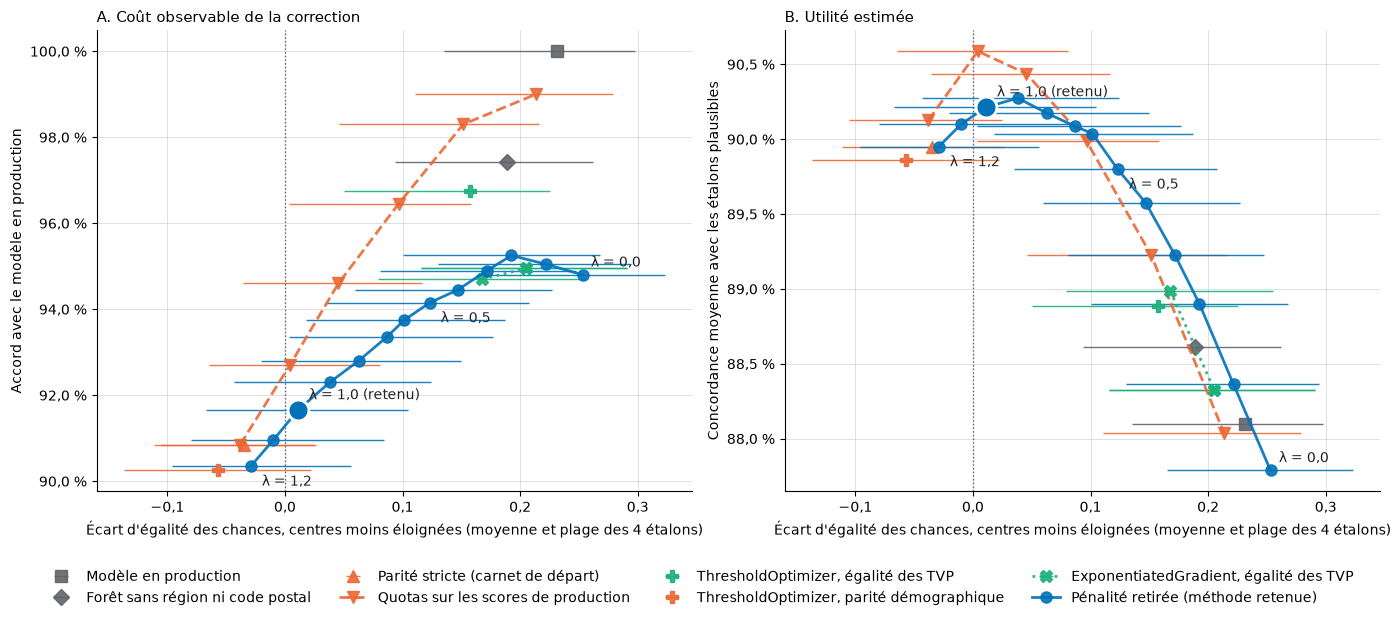

In [17]:
COULEUR_RETENUE = "#0072BA"
COULEUR_PARITE = "#eb6834"
COULEUR_TVP = "#1baf7a"
COULEUR_PRODUCTION = "#5f6368"
COULEUR_GRILLE = "#d0d4d9"
COULEUR_TEXTE = "#1f2328"
TAILLE_FIGURE = (14, 6.2)
RESOLUTION = 160
TAILLE_MARQUEUR = 8
TAILLE_MARQUEUR_RETENU = 15
EPAISSEUR_LIGNE = 2
EPAISSEUR_BARRE = 1
TAILLE_TEXTE = 10
OPACITE = 0.9
OPACITE_BARRES = 0.35
COLONNES_LEGENDE = 4
STYLES = {
    METHODE_PRODUCTION: (COULEUR_PRODUCTION, "s", "none"),
    METHODE_SANS_REGION: (COULEUR_PRODUCTION, "D", "none"),
    METHODE_PARITE: (COULEUR_PARITE, "^", "none"),
    METHODE_QUOTAS: (COULEUR_PARITE, "v", "--"),
    METHODE_SEUILS_PARITE: (COULEUR_PARITE, "P", "none"),
    METHODE_SEUILS_TVP: (COULEUR_TVP, "P", "none"),
    METHODE_GRADIENT: (COULEUR_TVP, "X", ":"),
}
DECALAGES_LAMBDA = {0.0: (6, 6), 0.5: (8, -14), LAMBDA_RETENU: (8, 8), 1.2: (8, -14)}


def barres_ecart(lignes):
    return [
        lignes["ecart_egalite_chances_moy"] - lignes["ecart_min"],
        lignes["ecart_max"] - lignes["ecart_egalite_chances_moy"],
    ]


def tracer_methode(axe, lignes, colonne_y, style, etiquette):
    couleur, marqueur, trait = style
    axe.errorbar(
        lignes["ecart_egalite_chances_moy"],
        lignes[colonne_y],
        xerr=barres_ecart(lignes),
        color=couleur,
        marker=marqueur,
        markersize=TAILLE_MARQUEUR,
        linestyle=trait,
        linewidth=EPAISSEUR_LIGNE,
        elinewidth=EPAISSEUR_BARRE,
        ecolor=to_rgba(couleur, OPACITE_BARRES),
        alpha=OPACITE,
        label=etiquette,
    )


def tracer_balayage(axe, colonne_y):
    tracer_methode(axe, balayage, colonne_y, (COULEUR_RETENUE, "o", "-"), METHODE_RETENUE)
    retenu = balayage.iloc[GRILLE_LAMBDA.index(LAMBDA_RETENU)]
    axe.plot(
        retenu["ecart_egalite_chances_moy"],
        retenu[colonne_y],
        marker="o",
        markersize=TAILLE_MARQUEUR_RETENU,
        markerfacecolor=COULEUR_RETENUE,
        markeredgecolor="white",
        markeredgewidth=EPAISSEUR_LIGNE,
        linestyle="none",
        zorder=5,
    )
    for part, decalage in DECALAGES_LAMBDA.items():
        point = balayage.iloc[GRILLE_LAMBDA.index(part)]
        suffixe = " (retenu)" if part == LAMBDA_RETENU else ""
        axe.annotate(
            libelle_lambda(part) + suffixe,
            (point["ecart_egalite_chances_moy"], point[colonne_y]),
            textcoords="offset points",
            xytext=decalage,
            fontsize=TAILLE_TEXTE,
            color=COULEUR_TEXTE,
        )


def tracer_panneau(axe, colonne_y, titre, libelle_y):
    axe.axvline(0.0, color=COULEUR_PRODUCTION, linestyle=":", linewidth=EPAISSEUR_BARRE)
    for methode, lignes in comparaisons.groupby("methode", sort=False):
        tracer_methode(axe, lignes, colonne_y, STYLES[methode], methode)
    tracer_balayage(axe, colonne_y)
    axe.set_title(titre, fontsize=TAILLE_TEXTE + 1, loc="left")
    axe.set_xlabel(
        f"Écart d'égalité des chances, centres moins éloignées (moyenne et plage des {len(etalons)} étalons)",
        fontsize=TAILLE_TEXTE,
    )
    axe.set_ylabel(libelle_y, fontsize=TAILLE_TEXTE)
    axe.grid(color=COULEUR_GRILLE, linewidth=EPAISSEUR_BARRE / 2)
    axe.spines[["top", "right"]].set_visible(False)
    axe.xaxis.set_major_formatter(FuncFormatter(lambda valeur, _: texte_nombre(valeur, 1)))
    axe.yaxis.set_major_formatter(FuncFormatter(lambda valeur, _: texte_pourcent(valeur)))


figure, (axe_production, axe_etalons) = plt.subplots(1, 2, figsize=TAILLE_FIGURE)
tracer_panneau(
    axe_production,
    "accord_production",
    "A. Coût observable de la correction",
    "Accord avec le modèle en production",
)
tracer_panneau(
    axe_etalons, "concordance_moy", "B. Utilité estimée", "Concordance moyenne avec les étalons plausibles"
)
poignees, etiquettes = axe_production.get_legend_handles_labels()
figure.legend(
    poignees, etiquettes, loc="lower center", ncol=COLONNES_LEGENDE, frameon=False, fontsize=TAILLE_TEXTE
)
figure.tight_layout(rect=(0, 0.1, 1, 1))
CHEMIN_FIGURE.parent.mkdir(exist_ok=True)
figure.savefig(CHEMIN_FIGURE, dpi=RESOLUTION, bbox_inches="tight", facecolor="white")
plt.show()

In [18]:
def point_balayage(part):
    return balayage.iloc[GRILLE_LAMBDA.index(part)]


def point_comparaison(methode, reglage):
    return comparaisons.set_index(["methode", "reglage"]).loc[(methode, reglage)]


depart, retenu, extreme = (
    point_balayage(part) for part in (GRILLE_LAMBDA[0], LAMBDA_RETENU, GRILLE_LAMBDA[-1])
)
seuils_tvp = point_comparaison(METHODE_SEUILS_TVP, REGLAGE_COMITE)
parite = point_comparaison(METHODE_PARITE, "forêt sans région, quotas par groupe")
equite_et_utilite = (
    abs(retenu.ecart_egalite_chances_moy) < abs(depart.ecart_egalite_chances_moy)
    and retenu.concordance_moy > depart.concordance_moy
)
lecture_tendance = (
    "Équité et utilité estimée progressent ensemble ; seul l'accord avec le modèle en production baisse."
    if equite_et_utilite and retenu.accord_production < depart.accord_production
    else "L'équité progresse au prix d'une partie de l'utilité estimée."
)
effet_extreme = "surcorrige" if extreme["ecart_egalite_chances_moy"] < 0 else "réduit encore l'écart"
part_concordance_max = GRILLE_LAMBDA[balayage["concordance_moy"].to_numpy().argmax()]
voisin_concordance = point_balayage(part_concordance_max)
lecture_choix_lambda = (
    f" La concordance moyenne un peu plus haute à {libelle_lambda(part_concordance_max)} "
    f"({texte_pourcent(voisin_concordance.concordance_moy, 2)} contre "
    f"{texte_pourcent(retenu.concordance_moy, 2)}) ne sert donc pas à choisir le réglage."
    if part_concordance_max != LAMBDA_RETENU
    else ""
)

quotas = comparaisons[comparaisons["methode"] == METHODE_QUOTAS].reset_index(drop=True)
quota_proche = quotas.loc[quotas["ecart_egalite_chances_moy"].abs().idxmin()]
ecart_vise_proche = ecarts_vises[quota_proche.name]
quota_parite_voisine = (quotas["ecart_parite"] - retenu.ecart_parite).abs().idxmin()
quotas_meilleurs = (
    abs(quota_proche.ecart_egalite_chances_moy) < abs(retenu.ecart_egalite_chances_moy)
    and quota_proche.concordance_moy > retenu.concordance_moy
)
lecture_quotas = "font un peu mieux" if quotas_meilleurs else "ne font pas mieux"
lecture_parite_quotas = (
    "est le plus proche de" if quota_parite_voisine == quota_proche.name else "n'est pas le plus proche de"
)
paires_identiques = [
    (borne, autre)
    for position, borne in enumerate(BORNES_GRADIENT)
    for autre in BORNES_GRADIENT[position + 1 :]
    if np.array_equal(decisions_gradient[borne], decisions_gradient[autre])
]
lecture_gradient = "".join(
    f" `ExponentiatedGradient` donne exactement les mêmes décisions avec les bornes "
    f"{texte_nombre(borne, 2)} et {texte_nombre(autre, 2)} : leurs points se confondent."
    for borne, autre in paires_identiques
)
afficher(
    f"De {libelle_lambda(GRILLE_LAMBDA[0])} à {libelle_lambda(LAMBDA_RETENU)}, l'écart moyen d'égalité des "
    f"chances "
    f"passe de {texte_signe(depart.ecart_egalite_chances_moy)} à "
    f"{texte_signe(retenu.ecart_egalite_chances_moy)}, "
    f"la concordance moyenne avec les étalons de {texte_pourcent(depart.concordance_moy)} à "
    f"{texte_pourcent(retenu.concordance_moy)}, et l'accord avec le modèle en production de "
    f"{texte_pourcent(depart.accord_production)} à {texte_pourcent(retenu.accord_production)}. "
    f"{lecture_tendance} "
    f"À {libelle_lambda(GRILLE_LAMBDA[-1])}, l'écart vaut {texte_signe(extreme.ecart_egalite_chances_moy)} : "
    f"retirer plus que la pénalité estimée {effet_extreme}. "
    f"{libelle_lambda(LAMBDA_RETENU)} est fixé d'avance : il retire exactement la pénalité estimée."
    f"{lecture_choix_lambda}\n\n"
    f"`ThresholdOptimizer` contraint à l'égalité des TVP sur les décisions du comité garde un écart réel de "
    f"{texte_signe(seuils_tvp.ecart_egalite_chances_moy)} (plage {texte_signe(seuils_tvp.ecart_min)} à "
    f"{texte_signe(seuils_tvp.ecart_max)}) : égaliser les TVP mesurés sur une étiquette biaisée conserve le "
    f"biais. "
    f"La parité stricte donne un écart moyen de {texte_signe(parite.ecart_egalite_chances_moy)} (plage "
    f"{texte_signe(parite.ecart_min)} à {texte_signe(parite.ecart_max)}) pour une concordance moyenne de "
    f"{texte_pourcent(parite.concordance_moy)}.\n\n"
    f"Les quotas sur les scores de production réglés sur un écart de parité visé de "
    f"{texte_nombre(ecart_vise_proche, 3)} {lecture_quotas} sur ces étalons : écart moyen "
    f"{texte_signe(quota_proche.ecart_egalite_chances_moy)} (plage {texte_signe(quota_proche.ecart_min)} à "
    f"{texte_signe(quota_proche.ecart_max)}), concordance moyenne "
    f"{texte_pourcent(quota_proche.concordance_moy)} contre {texte_pourcent(retenu.concordance_moy)}, "
    f"accord avec la production {texte_pourcent(quota_proche.accord_production)} contre "
    f"{texte_pourcent(retenu.accord_production)}. Ce réglage ne se repère qu'après coup, parmi "
    f"{texte_nombre(N_POINTS_QUOTAS)} écarts visés : son écart de parité "
    f"({texte_signe(quota_proche.ecart_parite)}) {lecture_parite_quotas} celui que produit la règle "
    f"corrigée ({texte_signe(retenu.ecart_parite)}), et il octroie par quota de groupe là où la méthode "
    f"retenue applique la même règle à tous.{lecture_gradient}"
)

De λ = 0,0 à λ = 1,0, l'écart moyen d'égalité des chances passe de +0,253 à +0,011, la concordance moyenne avec les étalons de 87,8 % à 90,2 %, et l'accord avec le modèle en production de 94,8 % à 91,6 %. Équité et utilité estimée progressent ensemble ; seul l'accord avec le modèle en production baisse. À λ = 1,2, l'écart vaut −0,029 : retirer plus que la pénalité estimée surcorrige. λ = 1,0 est fixé d'avance : il retire exactement la pénalité estimée. La concordance moyenne un peu plus haute à λ = 0,9 (90,27 % contre 90,21 %) ne sert donc pas à choisir le réglage.

`ThresholdOptimizer` contraint à l'égalité des TVP sur les décisions du comité garde un écart réel de +0,158 (plage +0,050 à +0,226) : égaliser les TVP mesurés sur une étiquette biaisée conserve le biais. La parité stricte donne un écart moyen de −0,035 (plage −0,112 à +0,027) pour une concordance moyenne de 90,0 %.

Les quotas sur les scores de production réglés sur un écart de parité visé de 0,039 font un peu mieux sur ces étalons : écart moyen +0,004 (plage −0,065 à +0,080), concordance moyenne 90,6 % contre 90,2 %, accord avec la production 92,7 % contre 91,6 %. Ce réglage ne se repère qu'après coup, parmi 6 écarts visés : son écart de parité (+0,039) est le plus proche de celui que produit la règle corrigée (+0,044), et il octroie par quota de groupe là où la méthode retenue applique la même règle à tous. `ExponentiatedGradient` donne exactement les mêmes décisions avec les bornes 0,05 et 0,10 : leurs points se confondent.

## 6. Pourquoi l'égalité des chances

Une bourse d'excellence doit donner la même chance aux candidat·es qui la méritent, quelle que soit leur région : c'est l'égalité des chances, mesurée par l'écart des TVP contre un étalon du mérite. C'est aussi la métrique du correcteur automatique. La parité démographique imposerait le même taux d'octroi dans les deux groupes alors que leurs profils diffèrent.

In [19]:
cote_r_groupes = candidats[COTE_R].groupby(groupe_candidats).mean()
taux_cote_r = taux_par_groupe(etalons["(a) cote R"])
decisions_parite_corrigee = selection_par_quotas(score_debiaise, quotas_pour_ecart(0.0))
octrois_deplaces = int((decisions_parite_corrigee != decisions).sum() // 2)
sens_deplacement = (
    "des grands centres vers les régions éloignées"
    if ecart_parite(decisions) > 0
    else "des régions éloignées vers les grands centres"
)
ecart_egalite_chances_parite_stricte = evaluer(decisions_parite_corrigee)["ecart_egalite_chances_moy"]
afficher(
    f"À l'évaluation, la cote R moyenne est de {texte_nombre(cote_r_groupes[CENTRE], 2)} dans les grands "
    f"centres "
    f"et de {texte_nombre(cote_r_groupes[ELOIGNEE], 2)} dans les régions éloignées ; l'étalon (a) octroie "
    f"{texte_pourcent(taux_cote_r[CENTRE])} et {texte_pourcent(taux_cote_r[ELOIGNEE])}.\n\n"
    f"Après correction, l'écart de parité résiduel est de {texte_signe(ecart_parite(decisions))} "
    f"({texte_pourcent(taux_groupes[CENTRE])} contre {texte_pourcent(taux_groupes[ELOIGNEE])}), contre "
    f"{texte_signe(ecart_parite(decisions_production))} pour le modèle en production. Imposer en plus la "
    f"parité "
    f"stricte au score débiaisé déplacerait {texte_nombre(octrois_deplaces)} octrois sur "
    f"{texte_nombre(nombre_octrois)} {sens_deplacement} et porterait l'écart moyen "
    f"d'égalité des chances de {texte_signe(sensibilite.ecart_egalite_chances.mean())} à "
    f"{texte_signe(ecart_egalite_chances_parite_stricte)}. Une fois la pénalité retirée, l'écart entre "
    "les deux métriques porte sur peu de décisions ; l'égalité des chances est retenue parce que les "
    "profils diffèrent."
)

À l'évaluation, la cote R moyenne est de 28,04 dans les grands centres et de 27,45 dans les régions éloignées ; l'étalon (a) octroie 42,9 % et 35,8 %.

Après correction, l'écart de parité résiduel est de +0,044 (41,8 % contre 37,4 %), contre +0,194 pour le modèle en production. Imposer en plus la parité stricte au score débiaisé déplacerait 42 octrois sur 1 600 des grands centres vers les régions éloignées et porterait l'écart moyen d'égalité des chances de +0,011 à −0,040. Une fois la pénalité retirée, l'écart entre les deux métriques porte sur peu de décisions ; l'égalité des chances est retenue parce que les profils diffèrent.

## 7. Plan de surveillance en production

En production, l'étalon n'est pas observé. Les indicateurs suivants se calculent sur chaque lot de décisions, sans vérité terrain :

- le taux d'octroi, contre l'enveloppe ;
- le taux d'octroi par région, contre la bande attendue : le taux de la règle corrigée appliquée aux décisions historiques, plus ou moins l'aléa d'échantillonnage de la région ;
- la pénalité régionale résiduelle : coefficient de région dans une régression logistique des décisions finales sachant les critères, exprimé en points de cote R (régression régularisée, pour rester définie quand les décisions sont une fonction exacte des critères) ;
- la prédictibilité de la région à partir des critères du score (AUC en validation croisée).

La fonction est appliquée à nos décisions, et aux décisions historiques du comité pour montrer qu'elle détecte la pénalité.

In [20]:
NIVEAU_BANDE = 0.95
Z_BANDE = norm.ppf((1 + NIVEAU_BANDE) / 2)
N_PLIS = 5
SEUIL_HAUSSE_AUC = 0.05
FRACTION_PENALITE_TOLEREE = 0.25

decisions_historique_corrigees = selectionner(score_comite(comite, x_demandes), demandes[IDENTIFIANT])
taux_attendus = pd.Series(decisions_historique_corrigees).groupby(demandes[REGION].to_numpy()).mean()


def bande_regions(lot, decisions_lot):
    resume = pd.Series(decisions_lot).groupby(lot[REGION].to_numpy()).agg(["size", "mean"])
    attendu = taux_attendus.reindex(resume.index)
    marge_region = Z_BANDE * np.sqrt(attendu * (1 - attendu) / resume["size"])
    return pd.DataFrame(
        {
            "n": resume["size"],
            "attendu": attendu,
            "borne_basse": attendu - marge_region,
            "borne_haute": attendu + marge_region,
            "observe": resume["mean"],
        }
    )


def penalite_points(lot, decisions_lot):
    x = matrice_comite(lot)
    poids = coefficients(LogisticRegression(max_iter=MAX_ITERATIONS).fit(x, decisions_lot), x)
    return poids[VARIABLE_ELOIGNEE] / poids[COTE_R] * ecarts_types[COTE_R]


def auc_region(lot):
    validation = StratifiedKFold(n_splits=N_PLIS, shuffle=True, random_state=GRAINE)
    scores = cross_val_score(
        LogisticRegression(max_iter=MAX_ITERATIONS),
        matrice_criteres(lot),
        lot[REGION].isin(REGIONS_ELOIGNEES),
        cv=validation,
        scoring="roc_auc",
    )
    return scores.mean(), scores.std(ddof=1)


def indicateurs_lot(lot, decisions_lot):
    bande = bande_regions(lot, decisions_lot)
    return {
        "taux d'octroi": decisions_lot.mean(),
        "régions hors bande": int(
            (~bande["observe"].between(bande["borne_basse"], bande["borne_haute"])).sum()
        ),
        "pénalité résiduelle (points de cote R)": penalite_points(lot, decisions_lot),
        "AUC de la région": auc_region(lot)[0],
    }


auc_reference, auc_ecart_type = auc_region(demandes)
seuil_penalite = FRACTION_PENALITE_TOLEREE * points_cote_r


def conformite(indicateurs):
    taux, hors_bande, penalite_lot, auc = indicateurs.values()
    return [
        taux_minimal <= taux <= taux_maximal,
        hors_bande == 0,
        abs(penalite_lot) <= seuil_penalite,
        auc <= auc_reference + SEUIL_HAUSSE_AUC,
    ]


def colonne_demonstration(indicateurs):
    taux, hors_bande, penalite_lot, auc = indicateurs.values()
    return [
        texte_pourcent(taux),
        texte_nombre(hors_bande),
        texte_signe(penalite_lot, 2),
        texte_nombre(auc, 3),
    ]


demonstration = {
    "décisions corrigées": indicateurs_lot(candidats, decisions),
    "comité historique": indicateurs_lot(demandes, demandes[CIBLE].to_numpy()),
}
tableau_demonstration = pd.DataFrame(index=list(demonstration["décisions corrigées"]))
for nom, indicateurs in demonstration.items():
    tableau_demonstration[nom] = colonne_demonstration(indicateurs)
    tableau_demonstration[f"conforme ({nom})"] = [
        "oui" if conforme else "non" for conforme in conformite(indicateurs)
    ]
display(tableau_demonstration)
display(bande_regions(candidats, decisions).round(3))

,décisions corrigées,conforme (décisions corrigées),comité historique,conforme (comité historique)
taux d'octroi,"40,0 %",oui,"39,9 %",oui
régions hors bande,0,oui,5,non
pénalité résiduelle (points de cote R),"0,00",oui,"−1,44",non
AUC de la région,"0,857",oui,"0,851",oui


,n,attendu,borne_basse,borne_haute,observe
Bas-Saint-Laurent,504,0.365,0.323,0.407,0.355
Capitale-Nationale,821,0.422,0.388,0.456,0.424
Cote-Nord,491,0.360,0.317,0.402,0.360
Gaspesie-Iles-de-la-Madeleine,633,0.375,0.338,0.413,0.400
Montreal,1551,0.421,0.397,0.446,0.415


Plan de surveillance proposé. Les seuils sont des propositions, chacune avec sa justification ; la cadence par défaut est trimestrielle.

In [21]:
SEUIL_DERIVE = 0.1
SEUIL_ECART_RECOURS = 0.05
DELAI_RECOURS_JOURS = 30
N_REVUE = 1000
HORIZONS_MOIS = (12, 24)
CRITERES_DERIVE = (*CRITERES_CONTINUS, DISTANCE)

ecarts_absolus_corriges = sensibilite["ecart_egalite_chances"].abs()
ecart_production_min = sensibilite["ecart_production"].min()
seuil_egalite_chances = round((ecarts_absolus_corriges.max() + ecart_production_min) / 2, 2)
tvp_moyen = np.mean(
    [
        taux_vrais_positifs(etalon, decisions, np.ones(len(decisions), dtype=bool))
        for etalon in etalons.values()
    ]
)
positifs_revue = N_REVUE * TAUX_CIBLE * effectifs / len(candidats)
erreur_type_revue = np.sqrt((tvp_moyen * (1 - tvp_moyen) / positifs_revue).sum())
points_ecart_type = penalite_ecart_type / coefficients_comite[COTE_R] * ecarts_types[COTE_R]
derive = (
    (candidats[list(CRITERES_DERIVE)].mean() - demandes[list(CRITERES_DERIVE)].mean())
    / demandes[list(CRITERES_DERIVE)].std()
).abs()
horizon_court, horizon_long = HORIZONS_MOIS

plan_surveillance = [
    {
        "indicateur": "Enveloppe d'octroi",
        "calcul": "taux d'octroi du lot",
        "seuil": f"entre {texte_pourcent(taux_minimal, 0)} et {texte_pourcent(taux_maximal, 0)}",
        "frequence": "à chaque lot",
        "responsable": "Direction des bourses",
        "action": "bloquer la publication et recalculer le seuil de score",
        "justification": "contrainte du mandat ; hors de la plage, les décisions du lot sont invalides",
    },
    {
        "indicateur": "Taux d'octroi par région",
        "calcul": "taux du lot par région, comparé au taux de la règle corrigée sur les décisions "
        "historiques",
        "seuil": f"dans la bande attendue, à {texte_nombre(Z_BANDE, 2)} erreurs-types",
        "frequence": "trimestrielle",
        "responsable": "Équipe de science des données",
        "action": "analyser les dossiers de la région ; deux trimestres hors bande : escalade au comité de "
        "gouvernance",
        "justification": f"la bande couvre l'aléa d'échantillonnage à {texte_pourcent(NIVEAU_BANDE, 0)} ; "
        f"au-delà, "
        "la règle ou la population a changé",
    },
    {
        "indicateur": "Pénalité régionale résiduelle",
        "calcul": "logit des décisions finales, dérogations du comité comprises, sachant les critères ; "
        "coefficient de région en points de cote R",
        "seuil": f"valeur absolue au plus {texte_nombre(seuil_penalite, 2)} point de cote R",
        "frequence": "trimestrielle",
        "responsable": "Responsable de l'équité",
        "action": "suspendre les dérogations manuelles, réexaminer les refus des régions éloignées, "
        "rapport au conseil d'administration",
        "justification": f"le comité appliquait {texte_nombre(points_cote_r, 2)} point ; le seuil en garde "
        f"{texte_pourcent(FRACTION_PENALITE_TOLEREE, 0)}, soit "
        f"{texte_nombre(seuil_penalite / points_ecart_type, 1)} écarts-types bootstrap de son estimation",
    },
    {
        "indicateur": "Prédictibilité de la région",
        "calcul": "AUC de la région prédite par les critères du score, en validation croisée",
        "seuil": f"au plus {texte_nombre(auc_reference, 3)} + {texte_nombre(SEUIL_HAUSSE_AUC, 2)}",
        "frequence": "trimestrielle",
        "responsable": "Équipe de science des données",
        "action": "revoir les variables proxys et tester leur retrait",
        "justification": f"référence historique {texte_nombre(auc_reference, 3)} (écart-type entre plis "
        f"{texte_nombre(auc_ecart_type, 3)}) ; une hausse signale un nouveau proxy de la région",
    },
    {
        "indicateur": "Revue aveugle du mérite",
        "calcul": f"{texte_nombre(N_REVUE)} dossiers tirés au hasard, notés sans la région par des "
        f"évaluateurs "
        "indépendants ; écart d'égalité des chances des décisions",
        "seuil": f"valeur absolue au plus {texte_nombre(seuil_egalite_chances, 2)}",
        "frequence": "trimestrielle",
        "responsable": "Comité de révision indépendant",
        "action": "réestimer la règle et réexaminer les dossiers du trimestre ; escalade au comité de "
        "gouvernance",
        "justification": f"entre l'écart maximal des décisions corrigées contre les étalons plausibles "
        f"({texte_nombre(ecarts_absolus_corriges.max(), 3)}) et l'écart minimal du modèle en production "
        f"({texte_nombre(ecart_production_min, 3)}) ; erreur-type de l'écart sur l'échantillon "
        f"{texte_nombre(erreur_type_revue, 3)}",
    },
    {
        "indicateur": "Égalité des chances a posteriori",
        "calcul": f"TVP par groupe, le mérite étant la persévérance ou la diplomation à {horizon_court} et "
        f"{horizon_long} mois",
        "seuil": f"valeur absolue au plus {texte_nombre(seuil_egalite_chances, 2)}",
        "frequence": "annuelle",
        "responsable": "Recherche institutionnelle",
        "action": "réviser la règle avec le comité d'éthique",
        "justification": "seule mesure du mérite fondée sur un résultat observé plutôt que sur un jugement",
    },
    {
        "indicateur": "Dérive des variables",
        "calcul": "valeurs inconnues (région, programme) ; différence standardisée des moyennes de la cote "
        "R, "
        "du revenu, des heures et de la distance par rapport à l'historique",
        "seuil": f"aucune valeur inconnue ; au plus {texte_nombre(SEUIL_DERIVE, 1)}",
        "frequence": "à chaque lot",
        "responsable": "Équipe de science des données",
        "action": "valeur inconnue : lot bloqué par la validation d'entrée ; dérive : réestimer la règle",
        "justification": f"seuil usuel de déséquilibre des covariables ; plus grande différence entre "
        f"l'historique et le lot d'évaluation : {texte_nombre(derive.max(), 3)}",
    },
    {
        "indicateur": "Recours",
        "calcul": "demandes de révision et décisions infirmées, par groupe",
        "seuil": f"écart des taux d'infirmation entre groupes au plus "
        f"{texte_nombre(100 * SEUIL_ECART_RECOURS)} points",
        "frequence": "trimestrielle",
        "responsable": "Bureau des recours",
        "action": f"réponse motivée sous {DELAI_RECOURS_JOURS} jours ; un écart déclenche l'audit des "
        f"dossiers",
        "justification": "le recours corrige les erreurs individuelles qu'aucun indicateur agrégé ne voit",
    },
]
ENTETES_SURVEILLANCE = (
    "Indicateur",
    "Calcul",
    "Seuil",
    "Fréquence",
    "Responsable",
    "Action",
    "Justification",
)


def tableau_markdown(lignes, entetes):
    rangees = ["| " + " | ".join(entetes) + " |", "|" + "---|" * len(entetes)]
    rangees += ["| " + " | ".join(ligne.values()) + " |" for ligne in lignes]
    return "\n".join(rangees)


afficher(tableau_markdown(plan_surveillance, ENTETES_SURVEILLANCE))

| Indicateur | Calcul | Seuil | Fréquence | Responsable | Action | Justification |
|---|---|---|---|---|---|---|
| Enveloppe d'octroi | taux d'octroi du lot | entre 36 % et 44 % | à chaque lot | Direction des bourses | bloquer la publication et recalculer le seuil de score | contrainte du mandat ; hors de la plage, les décisions du lot sont invalides |
| Taux d'octroi par région | taux du lot par région, comparé au taux de la règle corrigée sur les décisions historiques | dans la bande attendue, à 1,96 erreurs-types | trimestrielle | Équipe de science des données | analyser les dossiers de la région ; deux trimestres hors bande : escalade au comité de gouvernance | la bande couvre l'aléa d'échantillonnage à 95 % ; au-delà, la règle ou la population a changé |
| Pénalité régionale résiduelle | logit des décisions finales, dérogations du comité comprises, sachant les critères ; coefficient de région en points de cote R | valeur absolue au plus 0,36 point de cote R | trimestrielle | Responsable de l'équité | suspendre les dérogations manuelles, réexaminer les refus des régions éloignées, rapport au conseil d'administration | le comité appliquait 1,45 point ; le seuil en garde 25 %, soit 5,3 écarts-types bootstrap de son estimation |
| Prédictibilité de la région | AUC de la région prédite par les critères du score, en validation croisée | au plus 0,851 + 0,05 | trimestrielle | Équipe de science des données | revoir les variables proxys et tester leur retrait | référence historique 0,851 (écart-type entre plis 0,015) ; une hausse signale un nouveau proxy de la région |
| Revue aveugle du mérite | 1 000 dossiers tirés au hasard, notés sans la région par des évaluateurs indépendants ; écart d'égalité des chances des décisions | valeur absolue au plus 0,12 | trimestrielle | Comité de révision indépendant | réestimer la règle et réexaminer les dossiers du trimestre ; escalade au comité de gouvernance | entre l'écart maximal des décisions corrigées contre les étalons plausibles (0,104) et l'écart minimal du modèle en production (0,135) ; erreur-type de l'écart sur l'échantillon 0,033 |
| Égalité des chances a posteriori | TVP par groupe, le mérite étant la persévérance ou la diplomation à 12 et 24 mois | valeur absolue au plus 0,12 | annuelle | Recherche institutionnelle | réviser la règle avec le comité d'éthique | seule mesure du mérite fondée sur un résultat observé plutôt que sur un jugement |
| Dérive des variables | valeurs inconnues (région, programme) ; différence standardisée des moyennes de la cote R, du revenu, des heures et de la distance par rapport à l'historique | aucune valeur inconnue ; au plus 0,1 | à chaque lot | Équipe de science des données | valeur inconnue : lot bloqué par la validation d'entrée ; dérive : réestimer la règle | seuil usuel de déséquilibre des covariables ; plus grande différence entre l'historique et le lot d'évaluation : 0,025 |
| Recours | demandes de révision et décisions infirmées, par groupe | écart des taux d'infirmation entre groupes au plus 5 points | trimestrielle | Bureau des recours | réponse motivée sous 30 jours ; un écart déclenche l'audit des dossiers | le recours corrige les erreurs individuelles qu'aucun indicateur agrégé ne voit |

## 8. Décisions finales

`predictions.csv` est écrit à la racine du projet, dans l'ordre de `candidats_evaluation.csv`, en UTF-8 sans BOM avec des fins de ligne Unix.

In [22]:
predictions = pd.DataFrame({IDENTIFIANT: candidats[IDENTIFIANT], CIBLE: decisions})
predictions.to_csv(CHEMIN_PREDICTIONS, index=False, encoding="utf-8", lineterminator="\n")

Validation du fichier écrit, relu depuis le disque.

In [23]:
octets = CHEMIN_PREDICTIONS.read_bytes()
relu = pd.read_csv(CHEMIN_PREDICTIONS, dtype={IDENTIFIANT: str})
taux_relu = relu[CIBLE].mean()
controles = {
    "en-tête exact": octets.split(b"\n", 1)[0] == f"{IDENTIFIANT},{CIBLE}".encode(),
    "sans BOM": not octets.startswith(codecs.BOM_UTF8),
    "fins de ligne Unix": b"\r" not in octets,
    "nombre de lignes": len(relu) == len(candidats),
    "identifiants et ordre de l'évaluation": relu[IDENTIFIANT].tolist() == candidats[IDENTIFIANT].tolist(),
    "valeurs 0 ou 1": relu[CIBLE].isin(VALEURS_BINAIRES).all(),
    "nombre d'octrois": relu[CIBLE].sum() == nombre_octrois,
    "taux dans l'enveloppe": taux_minimal <= taux_relu <= taux_maximal,
}
display(pd.Series(controles, name="validé").to_frame())
exiger(all(controles.values()), "predictions.csv invalide")
afficher(
    f"`predictions.csv` : {texte_nombre(len(relu))} lignes, {texte_nombre(relu[CIBLE].sum())} octrois, "
    f"taux {texte_pourcent(taux_relu)}."
)

,validé
en-tête exact,True
sans BOM,True
fins de ligne Unix,True
nombre de lignes,True
identifiants et ordre de l'évaluation,True
valeurs 0 ou 1,True
nombre d'octrois,True
taux dans l'enveloppe,True


`predictions.csv` : 4 000 lignes, 1 600 octrois, taux 40,0 %.

`output/modele.json` reprend les résultats du carnet : nombres arrondis, taux en fractions.

In [24]:
def arrondir(valeur):
    if isinstance(valeur, dict):
        return {cle: arrondir(element) for cle, element in valeur.items()}
    if isinstance(valeur, list | tuple):
        return [arrondir(element) for element in valeur]
    if isinstance(valeur, np.generic):
        return arrondir(valeur.item())
    if isinstance(valeur, float):
        return round(valeur, DECIMALES_JSON)
    return valeur


def etendue(valeurs):
    return {"moyenne": np.mean(valeurs), "min": np.min(valeurs), "max": np.max(valeurs)}


modele_json = {
    "meta": {
        "date_execution": datetime.now().astimezone().isoformat(timespec="seconds"),
        "n_historique": len(demandes),
        "n_evaluation": len(candidats),
        "taux_octroi_cible": TAUX_CIBLE,
        "enveloppe": list(ENVELOPPE),
        "graine": GRAINE,
    },
    "modele_corrige": {
        "taux_octroi": decisions.mean(),
        "taux_par_groupe": taux_groupes.to_dict(),
        "taux_par_region": taux_regions.reset_index().to_dict("records"),
        "ecart_parite_eval": ecart_parite(decisions),
        "ecart_egalite_chances_ref": etendue(sensibilite["ecart_egalite_chances"]),
        "concordance_ref": etendue(sensibilite["concordance"]),
        "part_ecart_refermee": etendue(sensibilite["part_ecart_refermee"]),
        "exactitude_comite_test": exactitude_corrigee_test,
        "penalite_regionale": {
            "logit": penalite,
            "bootstrap_moyenne": penalite_moyenne,
            "bootstrap_ecart_type": penalite_ecart_type,
        },
        "stabilite": {"bascules_mediane": bascules_mediane, "bascules_max": bascules_max},
    },
    "front_pareto": front.to_dict("records"),
    "surveillance": plan_surveillance,
    "sensibilite": sensibilite.to_dict("records"),
}
CHEMIN_MODELE_JSON.parent.mkdir(exist_ok=True)
CHEMIN_MODELE_JSON.write_text(
    json.dumps(arrondir(modele_json), ensure_ascii=False, indent=2), encoding="utf-8"
)
afficher(
    f"`output/modele.json` écrit, nombres arrondis à {DECIMALES_JSON} décimales : {', '.join(modele_json)}."
)

`output/modele.json` écrit, nombres arrondis à 6 décimales : meta, modele_corrige, front_pareto, surveillance, sensibilite.

## 9. Références

- Carnet de départ `baseline_model.ipynb` et données `data/donnees_demandes.csv`, `data/candidats_evaluation.csv`, fournis par IVADO pour le défi ÉquiAlgo.
- Bird, S. et al. (2020). *Fairlearn*. Microsoft Research, rapport technique MSR-TR-2020-32.
- Hardt, M., Price, E. et Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. Advances in Neural Information Processing Systems (NeurIPS).
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12.

Outils d'IA utilisés : Claude (Anthropic) et OpenAI Codex, comme aide à l'écriture et à la vérification du code.